# Decision Tree Model for Wheat Futures Price Forecasting

**Student Name:** Mathew Martin  
**Date:** February 2026  
**Model:** Decision Tree Regressor  

This notebook implements a Decision Tree Regressor for forecasting wheat futures prices using FRED-MD macroeconomic features, following the `BaseForecastModel` abstract class.

In [28]:
"""
Imports
"""

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import pickle
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

print("Imports loaded!")

Imports loaded!


In [29]:
"""
Base Template for Forecasting Models
"""

class BaseForecastModel(ABC):

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train your model on the training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Make predictions on new data."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Evaluate model performance on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Save your trained model to a file."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Load a previously saved model."""
        pass


print("Base class defined!")

Base class defined!


In [30]:
"""
Data Loading Functions
"""

BASE = "/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models"

def load_fred_md(filepath):
    """Load a single FRED-MD vintage CSV."""
    print(f"Loading FRED-MD from: {filepath}")
    df = pd.read_csv(filepath)
    # First row is transformation codes — skip it
    df = df.iloc[1:].reset_index(drop=True)
    df['sasdate'] = pd.to_datetime(df['sasdate'], errors='coerce')
    df = df.dropna(subset=['sasdate']).set_index('sasdate')
    df.index.name = 'date'
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Normalise TWEX column name (older vintages use TWEXMMTH, newer use TWEXAFEGSMTHx)
    df.rename(columns={'TWEXMMTH': 'TWEXAFEGSMTHx'}, inplace=True)
    print(f"  → {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def load_wheat_futures(ticker="ZW=F", start_date="1999-01-01"):
    """Load wheat futures from Yahoo Finance."""
    print(f"Downloading {ticker} from Yahoo Finance...")
    df = yf.download(ticker, start=start_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    print(f"  → {df.shape[0]} rows")
    return df


def merge_fred_wheat(fred_df, wheat_df):
    """Merge FRED-MD with monthly wheat prices."""
    wheat_monthly = wheat_df['Close'].resample('ME').last()
    wheat_monthly.name = 'Wheat_Price'
    fred_df.index = fred_df.index.to_period('M')
    wheat_monthly.index = wheat_monthly.index.to_period('M')
    merged = fred_df.join(wheat_monthly.to_frame(), how='inner')
    # Drop columns with >30% missing, forward-fill, drop remaining NaN
    missing_pct = merged.isnull().sum() / len(merged)
    merged = merged.loc[:, missing_pct <= 0.3]
    merged = merged.ffill().dropna()
    print(f"  → Merged: {merged.shape[0]} rows, {merged.shape[1]} columns")
    return merged


# Features specified in Agriculture - Lab Meetings.pdf
# Note: WPSFD49502 (PPI) and VIXCLSx (VIX) excluded — not present in training vintages
# TWEXAFEGSMTHx: older vintages use TWEXMMTH (renamed above in load_fred_md)
SELECTED_FEATURES = [
    'RPI',              # Real Personal Income
    'DPCERA3M086SBEA',  # Real Personal Consumption Expenditures
    'RETAILx',          # Retail and Food Services Sales
    'INDPRO',           # Industrial Production Index
    'NDMANEMP',         # Employment: Nondurable Goods
    'ACOGNO',           # New Orders: Consumer Goods
    'BUSINVx',          # Total Business Inventories
    'BUSLOANS',         # Commercial & Industrial Loans
    'S&P 500',          # S&P 500 Stock Index
    'FEDFUNDS',         # Federal Funds Rate
    'GS10',             # 10-Year Treasury Rate
    'TWEXAFEGSMTHx',    # Trade Weighted USD Index
    'CUSR0000SAC',      # CPI: Commodities
    'DNDGRG3M086SBEA',  # PCE: Nondurable Goods Deflator
    'CES0600000008',    # Avg Hourly Earnings: Goods-Producing
    'UMCSENTx',         # Consumer Sentiment Index
    'DTCTHFNM',         # Total Consumer Loans and Leases
    'Wheat_Price',      # Target
]


def select_features(df, features=SELECTED_FEATURES):
    """Select subset of variables and drop any missing."""
    available = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  Warning — columns not found (skipped): {missing}")
    out = df[available].dropna()
    print(f"  → Selected {len(available)} variables, {len(out)} observations")
    return out


print("Data functions defined!")

Data functions defined!


In [31]:
# ============================================================================
# Load Data — Train / Validation / Test
# ============================================================================

# Wheat futures (shared across all splits)
wheat_df = load_wheat_futures("ZW=F")

# --- TRAINING: 1999-08 to 2014-12 (document-specified range) ---
print("\n--- TRAINING DATA ---")
train_fred = load_fred_md(f"{BASE}/Historical FRED-MD Vintages Final/2014-12.csv")
train_merged = merge_fred_wheat(train_fred, wheat_df)
train_data = select_features(train_merged)
train_data = train_data.loc['1999-08':'2014-12']  # Restrict to document-specified range
print(f"  → After date filter (1999-08 – 2014-12): {len(train_data)} observations")

# --- VALIDATION: 2015-01 to 2024-12 ---
print("\n--- VALIDATION DATA ---")
val_fred = load_fred_md(f"{BASE}/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv")
val_merged = merge_fred_wheat(val_fred, wheat_df)
val_data = select_features(val_merged)
val_data = val_data[val_data.index > train_data.index[-1]]

# --- TEST: 2026-01-MD.csv ---
print("\n--- TEST DATA ---")
test_fred = load_fred_md(f"{BASE}/2026-01-MD.csv")
test_merged = merge_fred_wheat(test_fred, wheat_df)
test_data = select_features(test_merged)
test_data = test_data[test_data.index > val_data.index[-1]]

print(f"\nFinal split sizes — Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Separate features and target
target = 'Wheat_Price'
feature_cols = [c for c in train_data.columns if c != target]

X_train, y_train = train_data[feature_cols], train_data[target]
X_val, y_val     = val_data[feature_cols],   val_data[target]
X_test, y_test   = test_data[feature_cols],  test_data[target]

print(f"Features: {feature_cols}")
train_data.head()

  → 6419 rows

--- TRAINING DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical FRED-MD Vintages Final/2014-12.csv
  → 671 rows, 126 columns
  → Merged: 173 rows, 127 columns
  → Selected 18 variables, 173 observations
  → After date filter (1999-08 – 2014-12): 173 observations

--- VALIDATION DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv
  → 791 rows, 126 columns
  → Merged: 293 rows, 127 columns
  → Selected 18 variables, 293 observations

--- TEST DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/2026-01-MD.csv
  → 804 rows, 126 columns
  → Merged: 306 rows, 127 col

,RPI,DPCERA3M086SBEA,RETAILx,INDPRO,NDMANEMP,ACOGNO,BUSINVx,BUSLOANS,S&P 500,FEDFUNDS,GS10,TWEXAFEGSMTHx,CUSR0000SAC,DNDGRG3M086SBEA,CES0600000008,UMCSENTx,DTCTHFNM,Wheat_Price
date,,,,,,,,,,,,,,,,,,
2000-07,10427.5,82.874,272638.0,92.6345,6393.0,125011.0,1175302.0,1068.6,1473.00,6.54,6.05,101.00,149.8,83.103,15.26,108.3,449083.0,246.0
2000-08,10477.3,83.313,272954.0,92.3191,6375.0,122095.0,1183156.0,1071.6,1485.46,6.50,5.83,102.55,149.2,82.677,15.32,107.3,456248.0,251.0
2000-09,10476.5,83.979,277523.0,92.6699,6356.0,126682.0,1183391.0,1072.9,1468.05,6.52,5.80,104.27,150.4,83.481,15.37,106.8,466633.0,258.0
2000-10,10492.2,83.943,276973.0,92.3486,6343.0,126059.0,1189984.0,1078.2,1390.14,6.51,5.74,105.88,150.1,83.272,15.45,105.8,484040.0,253.5
2000-11,10489.0,84.011,275928.0,92.3421,6323.0,126212.0,1197083.0,1080.4,1378.04,6.51,5.72,106.76,150.3,83.402,15.50,107.6,490228.0,252.5


In [32]:
"""
Decision Tree Forecast Model Implementation
"""

class DecisionTreeForecastModel(BaseForecastModel):
    """
    Decision Tree Regressor for commodity price forecasting.
    Inherits from BaseForecastModel and implements all required methods.
    """

    def __init__(self, task_type='regression', max_depth=10, min_samples_split=10,
                 min_samples_leaf=5, random_state=42):
        super().__init__(
            task_type=task_type, max_depth=max_depth,
            min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        )
        self.model = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=random_state,
        )
        self.feature_names = None
        self.is_fitted = False

    def fit(self, X_train, y_train):
        """Train the Decision Tree model."""
        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns.tolist()
            X_train = X_train.values
        if isinstance(y_train, (pd.Series, pd.DataFrame)):
            y_train = y_train.values.ravel()
        self.model.fit(X_train, y_train)
        self.is_fitted = True
        print(f"Model trained! Tree depth: {self.model.get_depth()}, Leaves: {self.model.get_n_leaves()}")

    def predict(self, X):
        """Make predictions on new data."""
        if not self.is_fitted:
            raise ValueError("Model not trained! Call fit() first.")
        if isinstance(X, pd.DataFrame):
            X = X.values
        return self.model.predict(X)

    def evaluate(self, X_test, y_test):
        """Compute evaluation metrics."""
        predictions = self.predict(X_test)
        if isinstance(y_test, (pd.Series, pd.DataFrame)):
            y_test = y_test.values.ravel()
        mse = mean_squared_error(y_test, predictions)
        return {
            'mse':  mse,
            'rmse': np.sqrt(mse),
            'mae':  mean_absolute_error(y_test, predictions),
            'r2':   r2_score(y_test, predictions),
        }

    def save(self, filepath: str):
        """Save the model."""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'model':         self.model,
                'feature_names': self.feature_names,
                'is_fitted':     self.is_fitted,
                'task_type':     self.task_type,
            }, f)
        print(f"Model saved to {filepath}")

    def load(self, filepath: str):
        """Load the model."""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.model         = data['model']
        self.feature_names = data['feature_names']
        self.is_fitted     = data['is_fitted']
        self.task_type     = data['task_type']
        print(f"Model loaded from {filepath}")

    def get_feature_importance(self):
        """Return feature importances sorted descending."""
        if not self.is_fitted:
            raise ValueError("Model not trained! Call fit() first.")
        if self.feature_names is None:
            self.feature_names = [f'feature_{i}' for i in range(len(self.model.feature_importances_))]
        return pd.DataFrame({
            'feature':    self.feature_names,
            'importance': self.model.feature_importances_,
        }).sort_values('importance', ascending=False).reset_index(drop=True)


print("DecisionTreeForecastModel defined!")

DecisionTreeForecastModel defined!


In [33]:
# ============================================================================
# Train Decision Tree Model
# ============================================================================

model = DecisionTreeForecastModel(
    task_type='regression',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)

model.fit(X_train, y_train)

Model trained! Tree depth: 9, Leaves: 30


In [34]:
# ============================================================================
# Evaluate Model
# ============================================================================

# Validation — Decision Tree predicts directly (no sliding window)
val_preds  = model.predict(X_val)
val_actual = y_val.values

mse = mean_squared_error(val_actual, val_preds)
print("=" * 40)
print("VALIDATION SET PERFORMANCE")
print("=" * 40)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {np.sqrt(mse):.4f}")
print(f"  MAE:  {mean_absolute_error(val_actual, val_preds):.4f}")
print(f"  R2:   {r2_score(val_actual, val_preds):.4f}")

# Test
if len(X_test) > 0:
    test_preds  = model.predict(X_test)
    test_actual = y_test.values

    mse_t = mean_squared_error(test_actual, test_preds)
    print("\n" + "=" * 40)
    print("TEST SET PERFORMANCE")
    print("=" * 40)
    print(f"  MSE:  {mse_t:.4f}")
    print(f"  RMSE: {np.sqrt(mse_t):.4f}")
    print(f"  MAE:  {mean_absolute_error(test_actual, test_preds):.4f}")
    print(f"  R2:   {r2_score(test_actual, test_preds):.4f}")
else:
    print("\nNo test data available.")

VALIDATION SET PERFORMANCE
  MSE:  20899.5575
  RMSE: 144.5668
  MAE:  103.8479
  R2:   -0.0242

TEST SET PERFORMANCE
  MSE:  623.1077
  RMSE: 24.9621
  MAE:  21.8132
  R2:   -1.7443


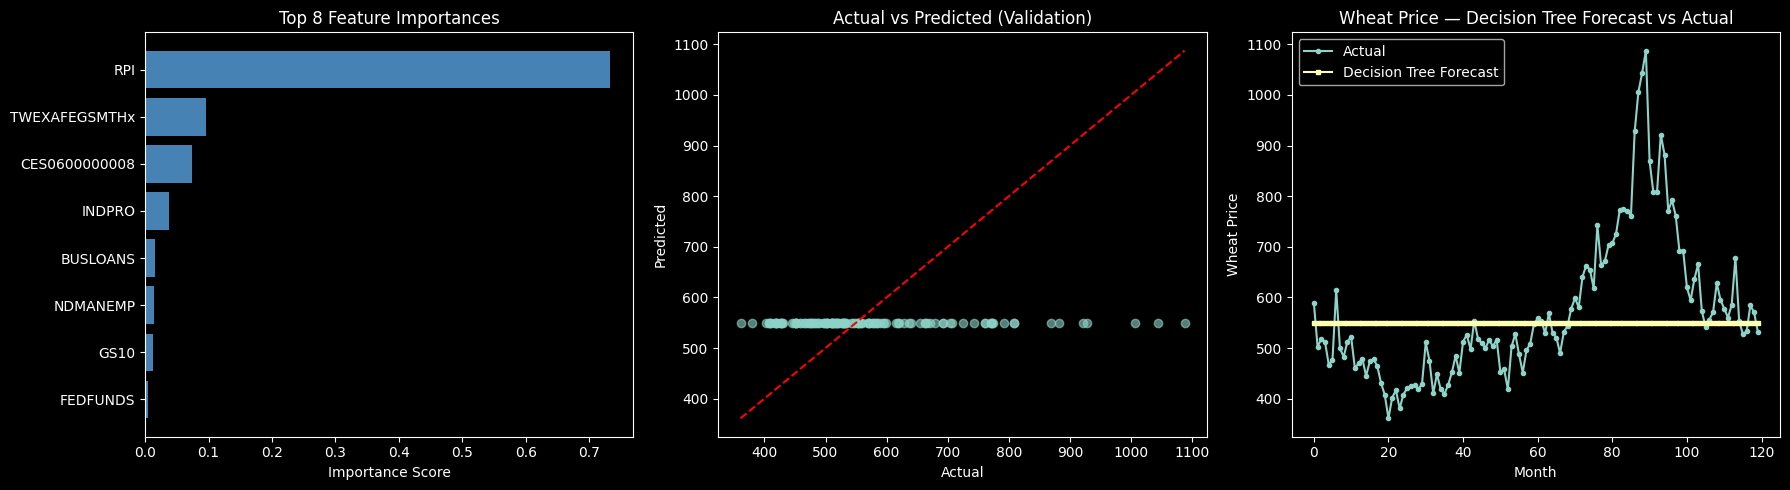

In [35]:
# ============================================================================
# Plot Results
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature Importance (top 8) — replaces training-loss panel for tree models
importance = model.get_feature_importance().head(8)
axes[0].barh(importance['feature'][::-1], importance['importance'][::-1], color='steelblue')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 8 Feature Importances')

# 2. Actual vs Predicted scatter (validation)
axes[1].scatter(val_actual, val_preds, alpha=0.6)
mn, mx = min(val_actual.min(), val_preds.min()), max(val_actual.max(), val_preds.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (Validation)')

# 3. Time series comparison (validation)
axes[2].plot(range(len(val_actual)), val_actual, label='Actual', marker='o', markersize=3)
axes[2].plot(range(len(val_preds)), val_preds, label='Decision Tree Forecast', marker='s', markersize=3)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Wheat Price')
axes[2].set_title('Wheat Price — Decision Tree Forecast vs Actual')
axes[2].legend()

plt.tight_layout()
plt.show()

In [36]:
# ============================================================================
# Save and Load Model
# ============================================================================

model.save('decision_tree_wheat_model.pkl')

# Load and verify
new_model = DecisionTreeForecastModel()
new_model.load('decision_tree_wheat_model.pkl')

# Verify predictions match
preds_orig   = model.predict(X_val)
preds_loaded = new_model.predict(X_val)
print(f"\nLoaded model matches: {np.allclose(preds_orig, preds_loaded)}")

Model saved to decision_tree_wheat_model.pkl
Model loaded from decision_tree_wheat_model.pkl

Loaded model matches: True
